# Delivery Time Prediction 

Predicts **actual delivery time (minutes)** using route and logistics features.

Models trained:
- Linear Regression (baseline)
- Random Forest Regressor (main model)


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported.")


Libraries imported.


## 2. Load & Inspect Data

In [2]:
df = pd.read_csv("delivery_data.csv")
print("Shape:", df.shape)
df.head(3)


Shape: (144867, 24)


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714


## 3. Feature Engineering

In [3]:
df["trip_creation_time"] = pd.to_datetime(df["trip_creation_time"])
df["hour_of_day"]  = df["trip_creation_time"].dt.hour
df["day_of_week"]  = df["trip_creation_time"].dt.dayofweek
df["month"]        = df["trip_creation_time"].dt.month


le = LabelEncoder()
df["route_type"] = le.fit_transform(df["route_type"])
df["is_cutoff"]  = df["is_cutoff"].astype(int)

print("Engineered features: hour_of_day, day_of_week, month")
print("Encoded: route_type (0=Carting, 1=FTL), is_cutoff (0/1)")
df[["hour_of_day", "day_of_week", "month", "route_type", "is_cutoff"]].head(3)


Engineered features: hour_of_day, day_of_week, month
Encoded: route_type (0=Carting, 1=FTL), is_cutoff (0/1)


,hour_of_day,day_of_week,month,route_type,is_cutoff
0,2,3,9,0,1
1,2,3,9,0,1
2,2,3,9,0,1


## 4. Define Features & Target

In [4]:
FEATURE_COLS = [
    "actual_distance_to_destination",
    "osrm_time",
    "osrm_distance",
    "segment_actual_time",
    "segment_osrm_time",
    "segment_osrm_distance",
    "segment_factor",
    "cutoff_factor",
    "start_scan_to_end_scan",
    "hour_of_day",
    "day_of_week",
    "month",
    "route_type",
    "is_cutoff",
]
TARGET = "actual_time"

train = df[df["data"] == "training"]
test  = df[df["data"] == "test"]

X_train = train[FEATURE_COLS];  y_train = train[TARGET]
X_test  = test[FEATURE_COLS];   y_test  = test[TARGET]

print(f"Training samples : {len(X_train):,}")
print(f"Test samples     : {len(X_test):,}")
print(f"Features used    : {len(FEATURE_COLS)}")
print(f"Target           : '{TARGET}'")


Training samples : 104,858
Test samples     : 40,009
Features used    : 14
Target           : 'actual_time'


## 5. Baseline Model — Linear Regression

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("Linear Regression Results:")
print(f"  MAE  : {mae_lr:.2f} min")
print(f"  RMSE : {rmse_lr:.2f} min")
print(f"  R²   : {r2_lr:.4f}")


Linear Regression Results:
  MAE  : 52.68 min
  RMSE : 110.27 min
  R²   : 0.9688


## 6. Main Model — Random Forest Regressor

In [7]:
print("Training Random Forest (100 trees, max_depth=12) ...")
rf = RandomForestRegressor(
n_estimators=100,
max_depth=12,
random_state=42,
n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Results:")
print(f"  MAE  : {mae_rf:.2f} min")
print(f"  RMSE : {rmse_rf:.2f} min")
print(f"  R²   : {r2_rf:.4f}")


Training Random Forest (100 trees, max_depth=12) ...

Random Forest Results:
  MAE  : 38.01 min
  RMSE : 86.09 min
  R²   : 0.9810


## 7. Model Comparison

In [8]:
results_df = pd.DataFrame({
    "Model":    ["Linear Regression", "Random Forest"],
    "MAE (min)":  [round(mae_lr, 2),  round(mae_rf, 2)],
    "RMSE (min)": [round(rmse_lr, 2), round(rmse_rf, 2)],
    "R² Score":   [round(r2_lr, 4),   round(r2_rf, 4)],
})
print(results_df.to_string(index=False))


            Model  MAE (min)  RMSE (min)  R² Score
Linear Regression      52.68      110.27    0.9688
    Random Forest      38.01       86.09    0.9810


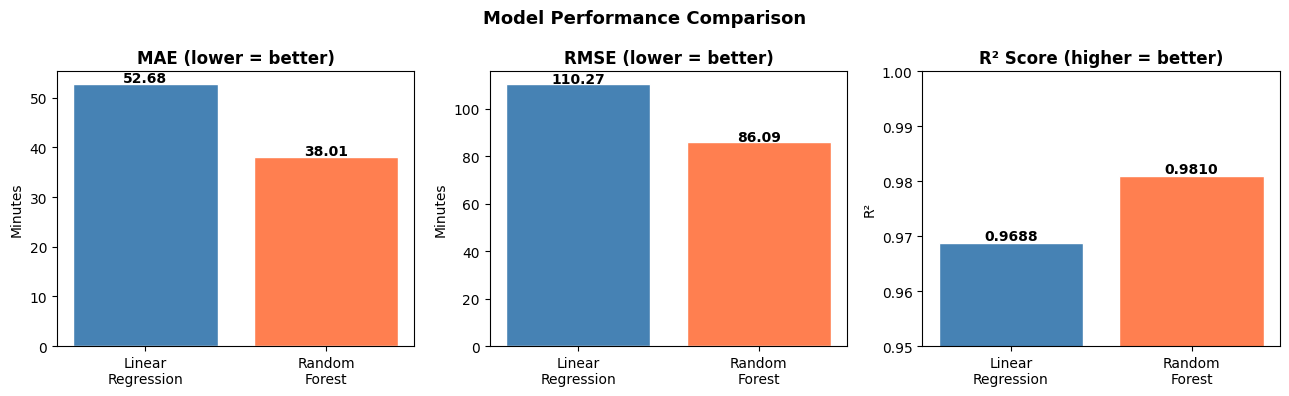

In [9]:
models_names = ["Linear\nRegression", "Random\nForest"]
maes  = [mae_lr,  mae_rf]
rmses = [rmse_lr, rmse_rf]
r2s   = [r2_lr,   r2_rf]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].bar(models_names, maes, color=["steelblue", "coral"], edgecolor="white")
axes[0].set_title("MAE (lower = better)", fontweight="bold")
axes[0].set_ylabel("Minutes")
for i, v in enumerate(maes):
    axes[0].text(i, v + 0.5, f"{v:.2f}", ha="center", fontweight="bold")

axes[1].bar(models_names, rmses, color=["steelblue", "coral"], edgecolor="white")
axes[1].set_title("RMSE (lower = better)", fontweight="bold")
axes[1].set_ylabel("Minutes")
for i, v in enumerate(rmses):
    axes[1].text(i, v + 0.5, f"{v:.2f}", ha="center", fontweight="bold")

axes[2].bar(models_names, r2s, color=["steelblue", "coral"], edgecolor="white")
axes[2].set_title("R² Score (higher = better)", fontweight="bold")
axes[2].set_ylim(0.95, 1.0)
axes[2].set_ylabel("R²")
for i, v in enumerate(r2s):
    axes[2].text(i, v + 0.0005, f"{v:.4f}", ha="center", fontweight="bold")

plt.suptitle("Model Performance Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=110, bbox_inches="tight")
plt.show()


## 8. Feature Importances (Random Forest)

In [10]:
fi = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

print("Feature Importances:")
print(fi.sort_values(ascending=False).round(4).to_string())


Feature Importances:
osrm_distance                     0.8606
actual_distance_to_destination    0.1078
start_scan_to_end_scan            0.0110
segment_actual_time               0.0056
cutoff_factor                     0.0053
hour_of_day                       0.0030
osrm_time                         0.0026
segment_factor                    0.0017
day_of_week                       0.0008
segment_osrm_distance             0.0008
segment_osrm_time                 0.0004
route_type                        0.0002
is_cutoff                         0.0001
month                             0.0000


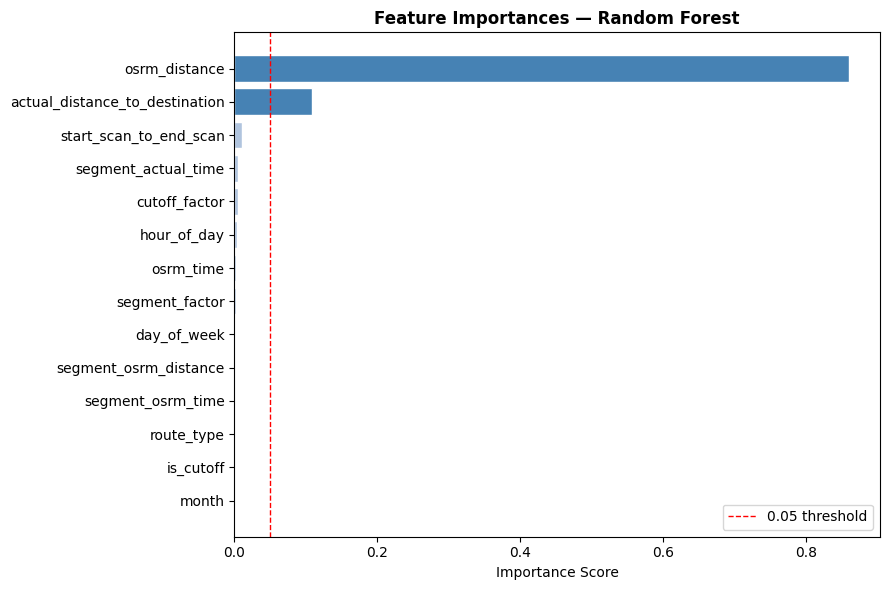

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = ["steelblue" if v > 0.05 else "lightsteelblue" for v in fi.values]
ax.barh(fi.index, fi.values, color=colors, edgecolor="white")
ax.set_title("Feature Importances — Random Forest", fontweight="bold")
ax.set_xlabel("Importance Score")
ax.axvline(0.05, color="red", linestyle="--", linewidth=1, label="0.05 threshold")
ax.legend()
plt.tight_layout()
plt.savefig("feature_importances.png", dpi=110, bbox_inches="tight")
plt.show()


## 9. Actual vs Predicted (Random Forest)

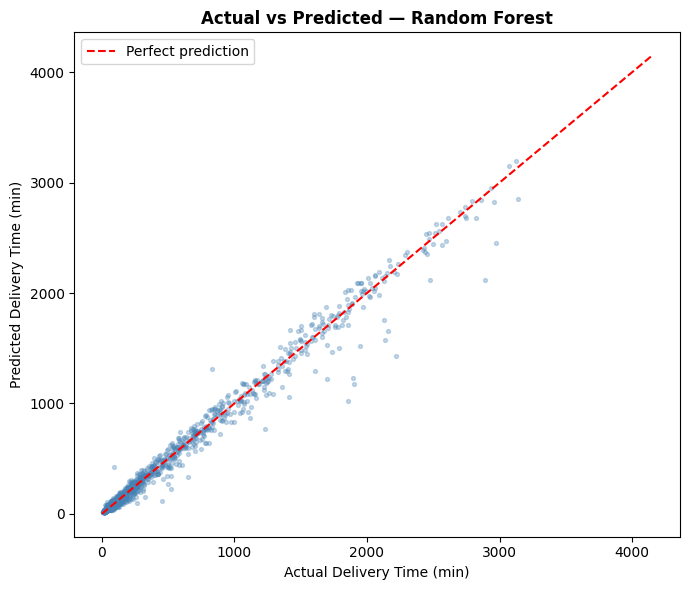

In [12]:
np.random.seed(42)
idx = np.random.choice(len(y_test), 1500, replace=False)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test.values[idx], y_pred_rf[idx], alpha=0.3, s=8, color="steelblue")
lim = max(y_test.max(), y_pred_rf.max())
ax.plot([0, lim], [0, lim], color="red", linestyle="--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual Delivery Time (min)")
ax.set_ylabel("Predicted Delivery Time (min)")
ax.set_title("Actual vs Predicted — Random Forest", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=110, bbox_inches="tight")
plt.show()


## 10. Residual Analysis

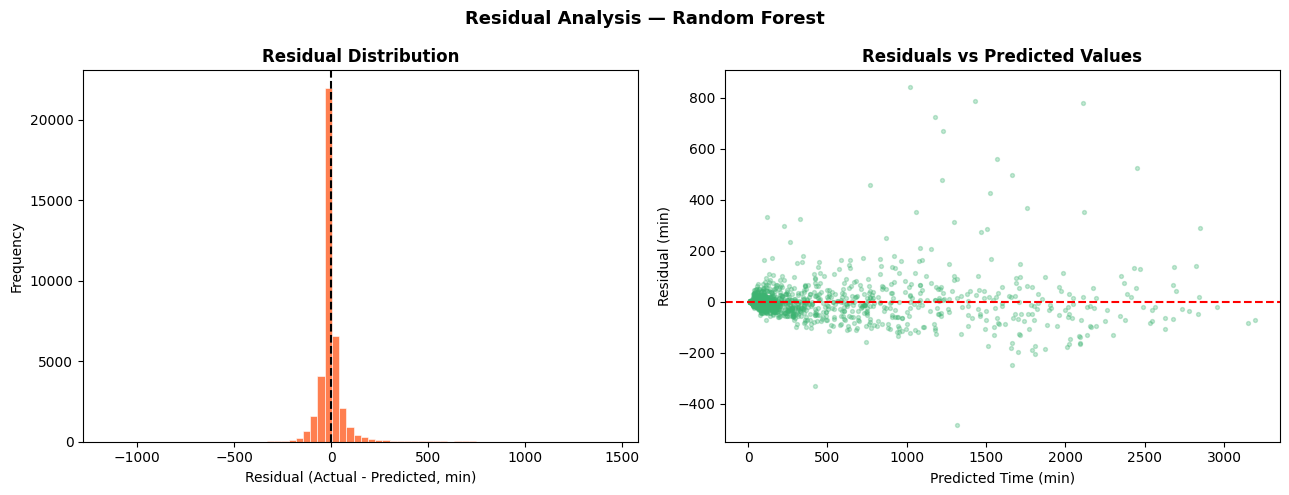

In [13]:
residuals = y_test.values - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(residuals, bins=70, color="coral", edgecolor="white", linewidth=0.4)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1.5)
axes[0].set_title("Residual Distribution", fontweight="bold")
axes[0].set_xlabel("Residual (Actual - Predicted, min)")
axes[0].set_ylabel("Frequency")

axes[1].scatter(y_pred_rf[idx], residuals[idx], alpha=0.3, s=8, color="mediumseagreen")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Residuals vs Predicted Values", fontweight="bold")
axes[1].set_xlabel("Predicted Time (min)")
axes[1].set_ylabel("Residual (min)")

plt.suptitle("Residual Analysis — Random Forest", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("residuals.png", dpi=110, bbox_inches="tight")
plt.show()


## 11. Save Predictions

In [14]:
submission = pd.DataFrame({
    "trip_uuid":          df[df["data"] == "test"]["trip_uuid"].values,
    "actual_time":        y_test.values,
    "predicted_time_lr":  np.round(y_pred_lr, 2),
    "predicted_time_rf":  np.round(y_pred_rf, 2),
})
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")
submission.head(5)


Saved submission.csv


,trip_uuid,actual_time,predicted_time_lr,predicted_time_rf
0,trip-153825970514894360,20.0,8.52,30.57
1,trip-153825970514894360,40.0,66.24,61.21
2,trip-153825970514894360,51.0,70.61,43.13
3,trip-153825970514894360,41.0,37.28,42.65
4,trip-153825970514894360,61.0,83.94,74.01


## 12. Summary

| Metric | Linear Regression | Random Forest |
|--------|:-----------------:|:-------------:|
| MAE (min) | 52.68 | **38.01** |
| RMSE (min) | 110.27 | **86.09** |
| R² Score | 0.9688 | **0.9810** |

**Key findings:**
- `osrm_distance` is by far the most predictive feature (importance ~0.86)
- `actual_distance_to_destination` is the second most important (~0.11)
- Random Forest improves MAE by ~14 minutes over Linear Regression
- Both models achieve high R² (>0.96), indicating OSRM routing features are strong predictors
- Time-of-day and day-of-week features have low individual importance but aid edge cases
